# Aruba population trends, 2015-2023


Source file: Table-1.11-Domiciliation-by-country-of-birth-and-sex.xlsx\
Source: CBS Aruba and the Population Registry Office

---
## 1. Setup

## Imports and paths

This block of code is necessary to create a reproducible notebook environment.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_RAW,
    FIGURES
)

In [2]:
# Verify all paths to ensure stable environment

print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
RAW DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/raw
FIGURES: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/outputs/figures


In [3]:
DOMICIL_COUNTRY_SEX = DATA_RAW / "Table-1.11-Domiciliation-by-country-of-birth-and-sex.xlsx"

In [4]:
# # Stop early if the source file is missing

if not DOMICIL_COUNTRY_SEX.exists():
    raise FileNotFoundError

## 2. Load and inspect source table

In [18]:
# Import data frame

raw_df = pd.read_excel(DOMICIL_COUNTRY_SEX, skiprows=1, header=None)

In [6]:
# Drop empty row 3 in data frame, reset index and turn all year values into integer

df = raw_df.dropna(how="all")
df.iloc[0] = pd.to_numeric(df.iloc[0], errors="coerce").astype("Int64")

In [7]:
# Promote first row to columns

df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

# Turn columns to a list type and name the empty column at index 0 with as 'indicator'

cols = df.columns.tolist()
cols[0] = "indicator"
df.columns = cols

# Turn columns back to a DataFrame and use ffill to fill all missing year values

cols = pd.Series(df.columns)
df.columns = cols.ffill()

In [19]:
# Rename data frame

clean_df = df

### 3. Loop (explaination)

Text

In [9]:
# Split the header into two different Series objects and create a for loop
# to join the header_top and header_bottom together

header_top = pd.Series(clean_df.columns)
header_bottom = clean_df.loc[0]

new_cols = []

for top, bottom in zip(header_top, header_bottom):
    if pd.isna(top):
        new_cols.append(str(bottom).strip())
    elif str(top) == "Indicator":
        new_cols.append("Indicator")
    else:
        new_cols.append(f"{top}_{str(bottom).strip()}")

In [10]:
# Reset index

clean_df.columns = new_cols
clean_df = clean_df.drop(index=0).reset_index(drop=True)

clean_df.tail()

,indicator_Country,2015_Male,2015_Female,2016_Male,2016_Female,2017_Male,2017_Female,2018_Male,2018_Female,2019_Male,2019_Female,2020_Male,2020_Female,2021_Male,2021_Female,2022_Male,2022_Female,2023_Male,2023_Female
3,Colombia,211,290,112,166,137,187,128,236,155,180,82,111,87,177,110,233,208,274
4,Venezuela,167,191,112,114,135,163,253,381,246,371,111,175,138,214,208,296,261,363
5,Dominican Republic,184,181,85,100,66,95,60,101,60,72,30,44,39,46,27,69,69,71
6,Other,416,398,256,255,230,266,298,321,238,313,135,138,203,208,246,256,294,322
7,Source: Population Registry Office,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Remove last row containing source information

clean_df = clean_df[
    ~clean_df["indicator_Country"].astype(str).str.startswith("Source:", na=False)
].reset_index(drop=True)

clean_df.head(3)

,indicator_Country,2015_Male,2015_Female,2016_Male,2016_Female,2017_Male,2017_Female,2018_Male,2018_Female,2019_Male,2019_Female,2020_Male,2020_Female,2021_Male,2021_Female,2022_Male,2022_Female,2023_Male,2023_Female
0,Total Domiciliation:,1780,1815,1264,1327,1291,1422,1420,1749,1312,1497,882,964,1015,1178,1174,1406,1455,1677
1,Aruba/ Neth. Ant.,432,420,415,389,429,416,424,407,382,345,338,295,362,322,344,344,368,382
2,The Netherlands,370,335,284,303,294,295,257,303,231,216,186,201,186,211,239,208,255,265


### 4. Convert to tidy format and create plot

In [12]:
# Convert to long format

tidy_df = clean_df.melt(
    id_vars = "indicator_Country",
    var_name = "year_sex",
    value_name = "value"
)

In [13]:
tidy_df.head(3)

,indicator_Country,year_sex,value
0,Total Domiciliation:,2015_Male,1780
1,Aruba/ Neth. Ant.,2015_Male,432
2,The Netherlands,2015_Male,370


In [14]:
# Split the original 'year_sex' column into two new columns labeled 'year' and 'sex'
# to make analysis possible by having separate observations
# Then delete the merged col

tidy_df[["year", "sex"]] = tidy_df["year_sex"].str.split("_", expand=True)

tidy_df = tidy_df.drop(columns="year_sex")

In [15]:
# Convert values to numeric

tidy_df["year"] = pd.to_numeric(tidy_df["year"], errors="coerce").astype("Int64")
tidy_df["value"] = pd.to_numeric(tidy_df["value"], errors="coerce")

tidy_df.iloc[1:,:]

,indicator_Country,value,year,sex
1,Aruba/ Neth. Ant.,432,2015,Male
2,The Netherlands,370,2015,Male
3,Colombia,211,2015,Male
4,Venezuela,167,2015,Male
5,Dominican Republic,184,2015,Male
...,...,...,...,...
121,The Netherlands,265,2023,Female
122,Colombia,274,2023,Female
123,Venezuela,363,2023,Female
124,Dominican Republic,71,2023,Female


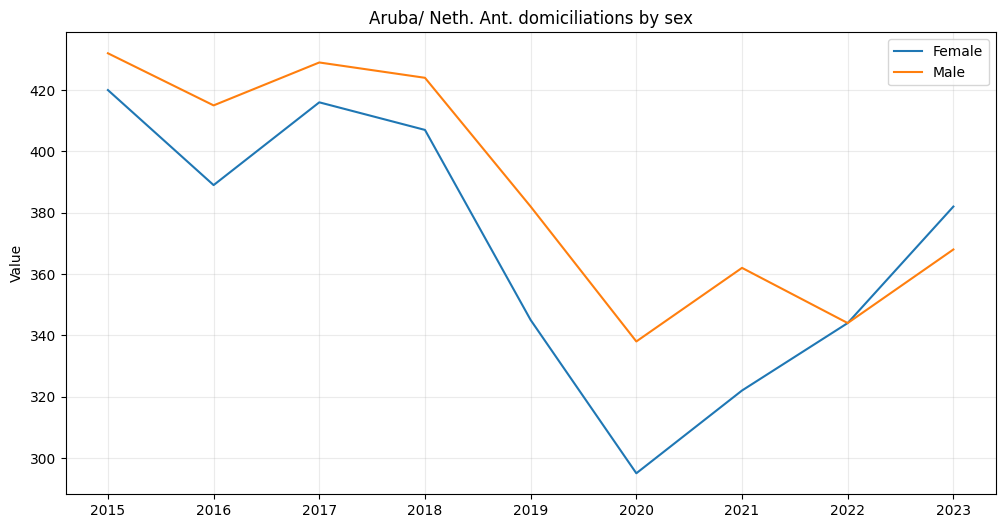

In [16]:
df_plot = tidy_df[tidy_df["indicator_Country"] == "Aruba/ Neth. Ant."].copy()

plt.figure(figsize=(12,6))
plt.grid(alpha=0.25)

for sex, group in df_plot.groupby("sex"):
    plt.plot(group["year"], group["value"], label=sex)

plt.title("Aruba/ Neth. Ant. domiciliations by sex")
plt.ylabel("Value")
plt.legend()
plt.show()

### 5. Subplots

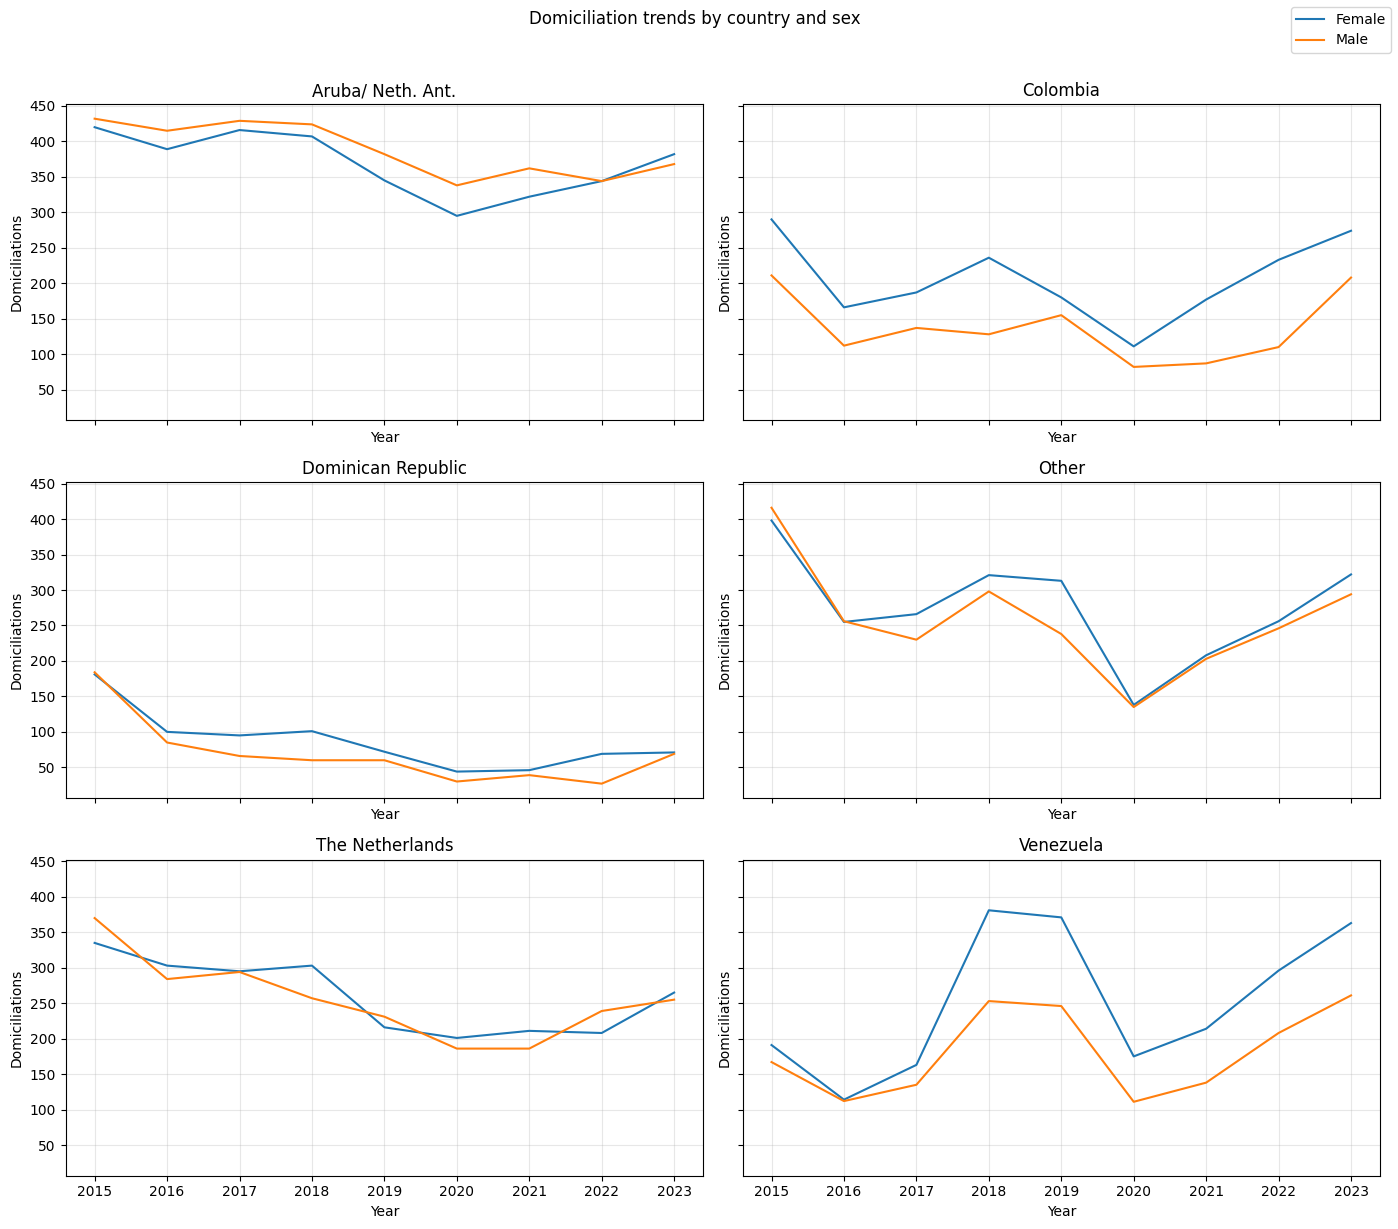

In [17]:
# Copy and clean
df_plot = tidy_df.copy()

# Keep only real country rows
df_plot = df_plot[
    ~df_plot["indicator_Country"].isin(["Total Domiciliation:"])
].copy()

df_plot = df_plot[
    ~df_plot["indicator_Country"].astype(str).str.startswith("Source:", na=False)
].copy()

# Make sure types are correct
df_plot["year"] = pd.to_numeric(df_plot["year"], errors="coerce")
df_plot["value"] = pd.to_numeric(df_plot["value"], errors="coerce")

# Optional: rename for readability
df_plot = df_plot.rename(columns={"indicator_Country": "country"})

# Sort values
df_plot = df_plot.sort_values(["country", "sex", "year"])

countries = df_plot["country"].unique()

n = len(countries)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    country_data = df_plot[df_plot["country"] == country]

    for sex, group in country_data.groupby("sex"):
        ax.plot(group["year"], group["value"], label=sex)

    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Domiciliations")
    ax.grid(True, alpha=0.3)

# Remove unused axes if any
for ax in axes[len(countries):]:
    fig.delaxes(ax)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=1)

fig.suptitle("Domiciliation trends by country and sex", y=1.02)
plt.tight_layout()

plt.savefig(FIGURES / "domicil_trends_country_sex.png", dpi=300, bbox_inches="tight")
plt.show()